# Netflix 데이터셋 EDA 와 seaborn 시각화

## EDA(Exploratory Data Analysis)란?

> **탐색적 데이터 분석**이란, 데이터를 본격적으로 분석하기 전에  
> 데이터의 특성·분포·패턴·이상값을 **시각화와 통계로 파악**하는 과정

### EDA의 목적
| 단계 | 질문 |
|------|------|
| 데이터 이해 | 컬럼이 몇 개? 각 컬럼의 타입은? 행이 몇 개? |
| 품질 확인 | 결측값이 있나? 중복 행은? 이상값은? |
| 분포 파악 | 값이 어떻게 퍼져 있나? 편향(skew)이 있나? |
| 관계 파악 | 변수끼리 연관성이 있나? 트렌드는? |

### 사용 데이터셋
- **출처**: Kaggle - Netflix Movies and TV Shows
- **파일**: `netflix_titles.csv`
- **크기**: 약 8,800행 × 12열
- **내용**: Netflix에 등록된 영화·TV Show의 메타데이터

| 컬럼명 | 설명 |
|--------|------|
| show_id | 고유 ID |
| type | Movie / TV Show |
| title | 제목 |
| director | 감독 |
| cast | 출연진 |
| country | 제작 국가 |
| date_added | Netflix 등록일 |
| release_year | 공개, 출시 연도 |
| rating | 시청 등급  |
| duration | 상영 시간(영화: 분) / 시즌 수(TV Show) |
| listed_in | 장르 |

## 1. 라이브러리 임포트 & 데이터 로딩

In [50]:
import pandas as pd  
import matplotlib.pyplot as plt
import seaborn as sns                  # matplotlib 기반 통계 시각화

In [51]:
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

In [52]:
df = pd.read_csv('netflix_titles.csv')
df.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


## 2. 데이터 기본 정보 확인

#### `df.info()`
- 각 컬럼의 **데이터 타입**, **비결측 데이터 수**, **메모리 사용량** 출력
- `object` 또는 'str' 타입 = 문자열, `int64`/`float64` = 숫자
- 결측값 존재 시 Non-Null Count가 전체 행 수보다 작게 표시됨

#### `df.describe()`
- **수치형 컬럼**의 기초 통계량 자동 계산

| 통계량 | 의미 |
|--------|------|
| `count` | 결측값 제외 데이터 수 |
| `mean` | 평균 |
| `std` | 표준편차 (값이 평균에서 얼마나 퍼져 있는지) |
| `min` / `max` | 최솟값 / 최댓값 |
| `25%` / `50%` / `75%` | 1사분위수 / 중앙값 / 3사분위수 |

> **참고**: describe(` include='object'`) 를 사용하면 문자열 컬럼도 통계 확인 가능

In [ ]:
df.info()

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


#### describe(include='object'): 문자열(범주형) 컬럼의 통계
- count: 비결측값 수 / unique: 고유값 수 / top: 최빈값 / freq: 최빈값 등장 횟수

In [ ]:
df.describe(include='str')

In [54]:
df.describe(include='object')

,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,3207,1793,362,4


In [ ]:
df.nunique()

In [55]:
df.nunique()

show_id         8807
type               2
title           8807
director        4528
cast            7692
country          748
date_added      1767
release_year      74
rating            17
duration         220
listed_in        514
description     8775
dtype: int64

## 3. 결측값 분석 및 처리

### 결측값(Missing Value)이란?
데이터가 수집되지 않아 비어 있는 셀. Python/pandas에서는 `NaN`(Not a Number)으로 표현됨.

### 결측값 탐지 함수

```python
df.isnull()          # 결측이면 True, 아니면 False인 DataFrame 반환
df.isnull().sum()    # 컬럼별 결측값 수 집계
```

### 결측값 처리 전략

| 전략 | 함수 | 적합한 상황 |
|------|------|------------|
| **제거** | `df.dropna()` | 결측 비율이 낮고(< 5%) 데이터가 충분할 때 |
| **대체 (평균/중앙값)** | `df.fillna(df.mean())` | 수치형 컬럼, 분포가 정규분포에 가까울 때 |
| **대체 (최빈값)** | `df.fillna(df.mode()[0])` | 범주형 컬럼 |
| **대체 (고정값)** | `df.fillna('Unknown')` | 문자열 컬럼, 결측 자체가 '정보 없음'을 의미 |


> **주의**: 무조건 제거하면 데이터 손실이 크고, 무조건 평균으로 채우면 분포가 왜곡될 수 있음.
> 항상 **결측 원인과 비율을 고려**하여 전략을 선택할 것!

In [56]:
df.isnull().sum() 

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [18]:
len(df)

8807

In [57]:
len(df)

8807

In [ ]:
(df.isnull().sum()  /   len(df) *100).round(2)

In [58]:
(df.isnull().sum()  /   len(df) *100).round(2)

show_id          0.00
type             0.00
title            0.00
director        29.91
cast             9.37
country          9.44
date_added       0.11
release_year     0.00
rating           0.05
duration         0.03
listed_in        0.00
description      0.00
dtype: float64

### Netflix 데이터의 결측값 처리 계획

| 컬럼 | 결측 비율 | 처리 방법 | 이유 |
|------|----------|----------|------|
| `director` | ~30% | `'Unknown'`으로 대체 | 제거 시 데이터 30% 손실 |
| `cast` | ~9% | `'Unknown'`으로 대체 | 결측 = '정보 없음' 의미 |
| `country` | ~9% | `'Unknown'`으로 대체 | 동일 |
| `rating` | < 0.1% | `'Unknown'`으로 대체 | 매우 소수 |
| `date_added` | < 0.1% | 해당 행 제거 | 시계열 분석에 필수 컬럼 |
| `duration` | < 0.1% | 해당 행 제거 | 소수  |

In [59]:
df['director'] = df['director'].fillna('Unknown')

In [60]:
df['cast'] = df['cast'].fillna('Unknown')

In [61]:
df['country'] = df['country'].fillna('Unknown')

In [62]:
df['rating'] = df['rating'].fillna('Unknown')

#### 위의 fillna() 이해한 학생은 앞으론 다음의 for 문으로 하면 됩니다
``` python
for col in ['director', 'cast', 'country', 'rating']:
    df[col] = df[col].fillna('Unknown')
```

#### dropna() 다음과 같이 사용하니 이해한 후 눈으로 익혀주세요

In [ ]:
df = df.dropna(subset=['date_added', 'duration'])

In [63]:
df = df.dropna(subset=['date_added', 'duration'])

### 날짜 컬럼 변환  (매우 중요!! 꼭 기억하세요!!)
#### pd.to_datetime(): 문자열 → datetime 객체로 변환 (날짜 연산 가능해짐)
> 이 데이터에서 특수하게 ' August 4, 2017' 에 공백이 있음
   str.strip()으로 앞뒤 공백 제거

In [64]:
df.head(1)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."


In [67]:
df['date_added'].str.strip()

0       September 25, 2021
1       September 24, 2021
2       September 24, 2021
3       September 24, 2021
4       September 24, 2021
               ...        
8802     November 20, 2019
8803          July 1, 2019
8804      November 1, 2019
8805      January 11, 2020
8806         March 2, 2019
Name: date_added, Length: 8794, dtype: object

In [68]:
pd.to_datetime(df['date_added'].str.strip())

0      2021-09-25
1      2021-09-24
2      2021-09-24
3      2021-09-24
4      2021-09-24
          ...    
8802   2019-11-20
8803   2019-07-01
8804   2019-11-01
8805   2020-01-11
8806   2019-03-02
Name: date_added, Length: 8794, dtype: datetime64[ns]

In [69]:
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())

In [71]:
df['year'] = df['date_added'].dt.year

In [72]:
df['month'] = df['date_added'].dt.month

In [73]:
df['day'] = df['date_added'].dt.day

In [74]:
df.head(1)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year,month,day
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9,25


### seaborn 시각화 연습

문제 1: 컨텐츠가 등록된 연도 year 기준 countplot을 그리시오.

<Axes: xlabel='year', ylabel='count'>

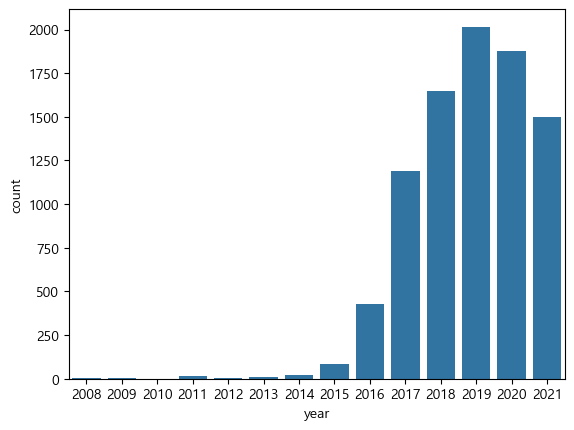

In [75]:
sns.countplot(data=df, x='year')

문제 2: 컨텐츠가 등록된 연도 year 기준 type을 hue로 설정하여 시각화하시오

<Axes: xlabel='year', ylabel='count'>

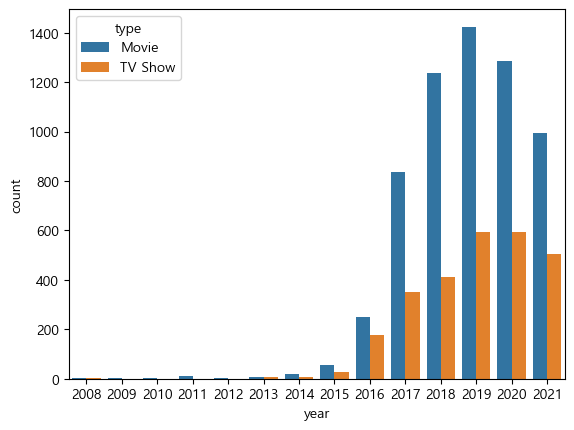

In [76]:
sns.countplot(data=df, x='year', hue='type')

문제 3: release_year를 histplot으로 시각화하시오.

<Axes: xlabel='release_year', ylabel='Count'>

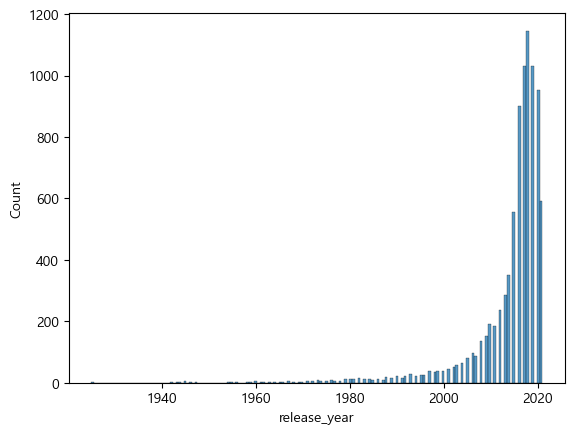

In [77]:
sns.histplot(data=df, x='release_year')

문제 4: bins를 20으로 설정하여 위의 release_year 분포를 다시 그리시오.

<Axes: xlabel='release_year', ylabel='Count'>

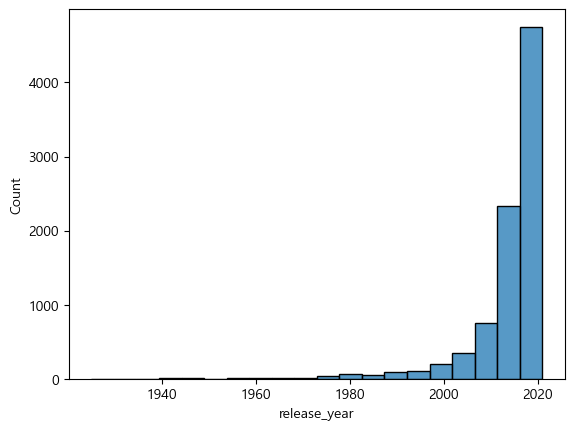

In [83]:
sns.histplot(data=df, x='release_year', bins=20)

<Axes: xlabel='release_year', ylabel='Count'>

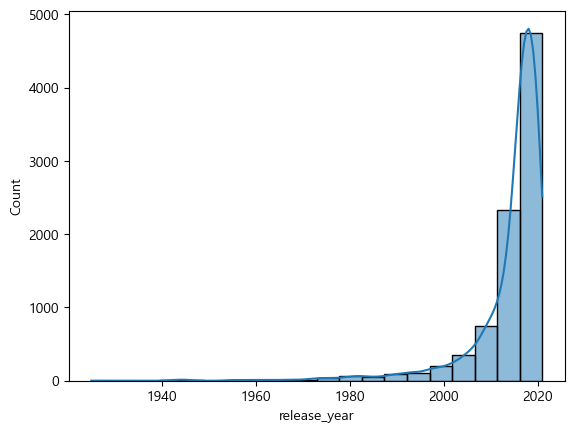

In [79]:
sns.histplot(data=df, x='release_year', bins=20, kde=True)

문제 5: release_year 분포 히스토그램을 type별로 hue를 사용하여 시각화하시오.

<Axes: xlabel='release_year', ylabel='Count'>

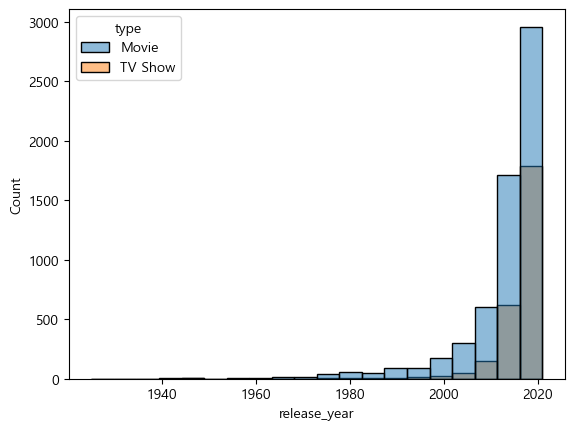

In [80]:
sns.histplot(data=df, x='release_year', hue='type', bins=20)

<Axes: xlabel='release_year', ylabel='Count'>

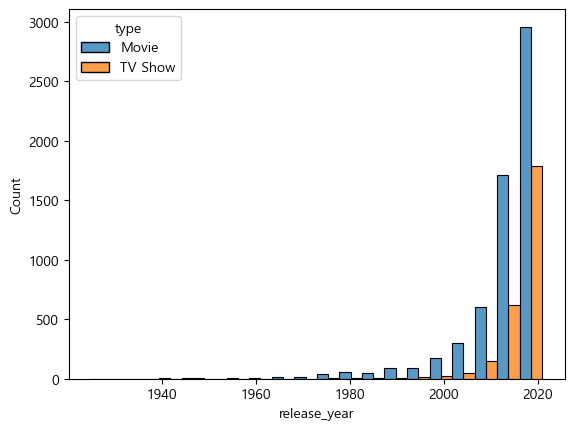

In [82]:
sns.histplot(data=df, x='release_year', hue='type', bins=20, multiple='dodge')

문제 6: type에 따른 넷플릭스에 공개된 평균 year 를 barplot() 으로 그리시오.

<Axes: xlabel='type', ylabel='year'>

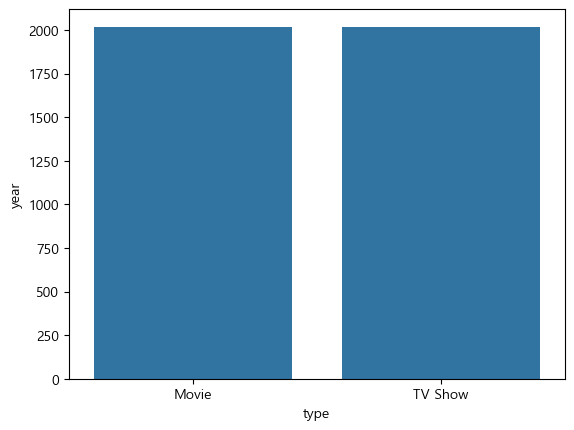

In [84]:
sns.barplot(data=df, x='type', y='year')

문제 7: type에 따른 넷플릭스에 공개된 평균 month 를 barplot() 으로 그리시오.

<Axes: xlabel='type', ylabel='month'>

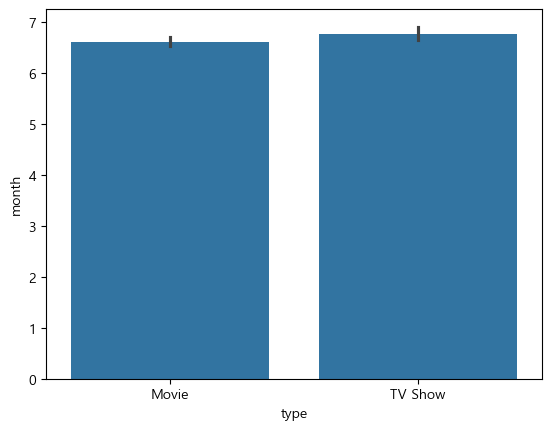

In [85]:
sns.barplot(data=df, x='type', y='month')

문제 8: rating에 따른 넷플릭스에 공개된 평균 month 를 boxplot() 으로 그리시오.

<Axes: xlabel='rating', ylabel='month'>

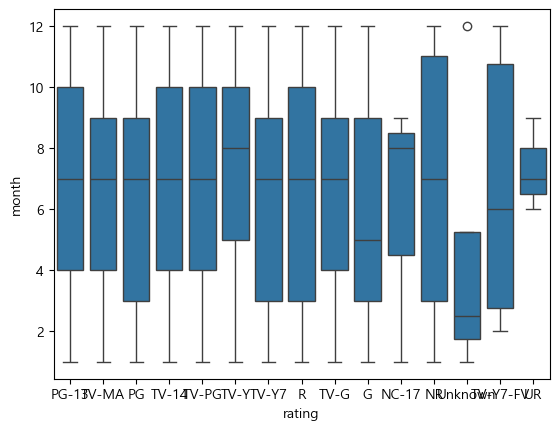

In [86]:
sns.boxplot(data=df, x='rating', y='month')

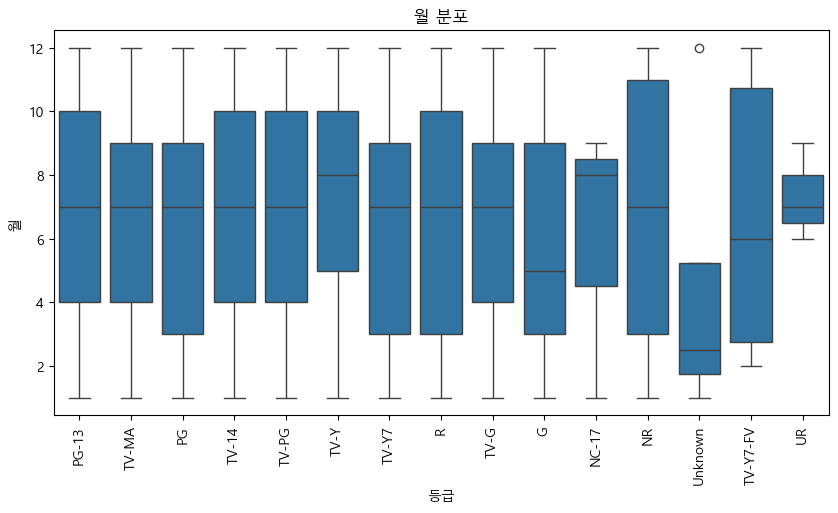

In [87]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='rating', y='month')
plt.title('월 분포')
plt.xlabel('등급')
plt.ylabel('월')
plt.xticks(rotation=90)
plt.show()

문제 9: type 에 따른 평균 컨텐츠 등록연도 (year) 를 violinplot() 으로 그리시오.

<Axes: xlabel='type', ylabel='year'>

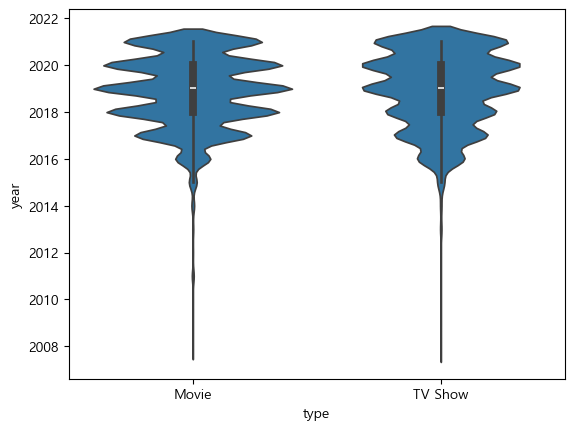

In [88]:
sns.violinplot(data=df, x='type', y='year')

문제 10: 여러분이 문제를 적고 seaborn 함수를 사용해 시각화하고 plt.title() 등으로 장식도 해보세요

In [ ]:
연도별 출시 콘텐츠 수가 가장 많은 연도 Top3를 시각화

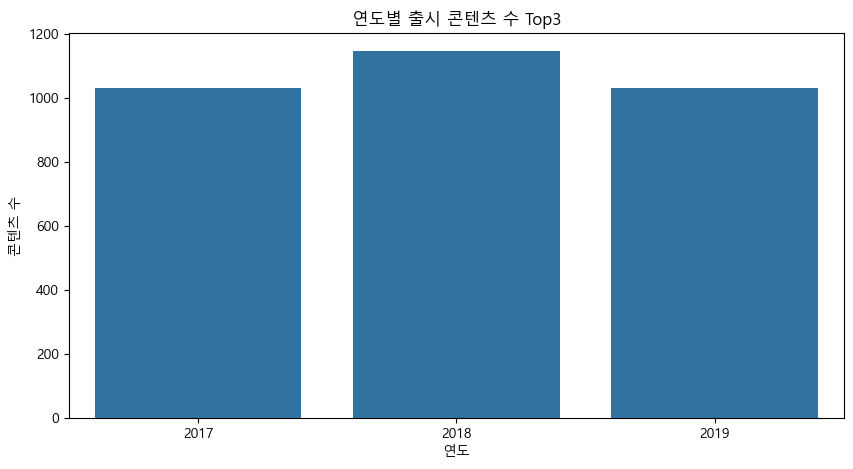

In [101]:
top3 = df['release_year'].value_counts().head(3)
plt.figure(figsize=(10, 5))
sns.barplot(x=top3.index, y=top3.values)

plt.title('연도별 출시 콘텐츠 수 Top3')
plt.xlabel('연도')
plt.ylabel('콘텐츠 수')
plt.show()

여러분 이번 주도 열심히 공부하고 실습해서 칭찬합니다!!  
내용이 조금 복잡해져도 걱정하지 마세요 계속 연습하고 실습하니 익숙해질거에요   
그래야 여러분이 AI 를 잘 활용하여 멋진 일들을 **주도적으로** 할 수 있어요   
공부하며 알게 된 것, 어려웠던 점, 교수에게 전할 말등을 아래에 꼭 적어 주세요    
**우리는 한 팀**  잊지 마시고 홧팅해요!!

프로그래머스 외에 국내사이트 중에 데이터 분석 문제를 풀어보거나 연습할 수 있는 추천 사이트가 있을까요?